# Three rainfall regimes, a link network, and what limits the map

The demonstration of `rainfall_field_sim` step by step: three regimes at comparable mean
rain, a CML network with the full sensor chain over them, and the field reconstructed from
what the links report - separating the error of the network's geometry from that of the
sensors. The README has the discussion; this notebook shows each number being made.
About a minute (the network-density sweep is left to `run_demo.py`).

In [1]:
import sys
import tempfile
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import pandas as pd
from IPython.display import Image, display

import figures
import run_demo
from core import viz_style as vs
from core.simulation.cml_network import SensorConfig, synthesize_network
from core.simulation.rain_fields import MODELS, Grid
vs.use_style()
OUT = Path(tempfile.mkdtemp())

## The three regimes

A 32 x 32 km periodic domain at 250 m. Stratiform: a spectral Gaussian field through a
threshold-and-power transform; convective: compact anisotropic cells on a weak background;
frontal: an analytic squall-line profile with along-band modulation.

In [2]:
grid = Grid(n=128, dx_km=0.25)
fields, stats = run_demo.build_fields(grid)
pd.DataFrame(stats).T[["war", "imf", "cmf", "max", "decorrelation_km", "frac_flux_top5pct"]].round(2)

,war,imf,cmf,max,decorrelation_km,frac_flux_top5pct
stratiform,0.86,1.89,2.20,7.57,5.86,0.15
convective,0.20,2.47,12.61,97.35,1.88,0.69
frontal,0.52,3.99,7.74,76.62,2.79,0.51


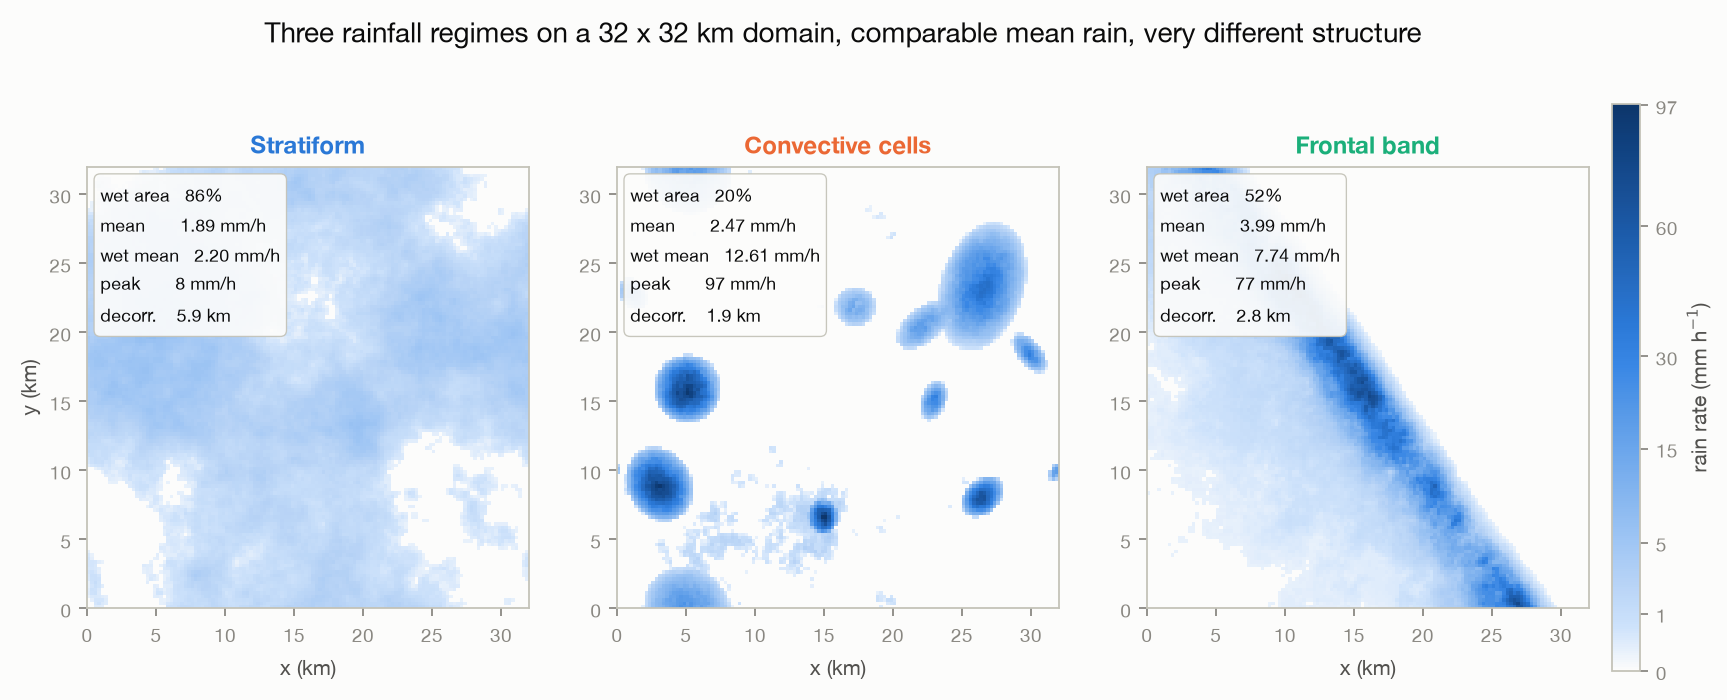

In [3]:
display(Image(str(figures.fig_fields(MODELS, fields, stats, grid, OUT / "fields.png") or OUT / "fields.png")))

## The network and the sensor chain

90 links from a plausible backhaul topology; each reports the ITU-R path integral plus wet
antenna, baseline error, noise and quantisation, and is retrieved with deliberately
mismatched wet-antenna coefficients.

In [4]:
cfg = SensorConfig()
net = synthesize_network(grid, n_links=90)
results = run_demo.run_sensors(fields, grid, net, cfg)
recon = run_demo.run_reconstruction(fields, grid, net, results)
run_demo.print_summary(net, stats, results, recon, cfg)


------------------------------------------------------------------------------
FIELD STATISTICS
------------------------------------------------------------------------------
model               wet area     mean  wet mean    peak   decorr  top 5% of area
                         (%)   (mm/h)    (mm/h)  (mm/h)     (km) holds (% water)
Stratiform              86.0     1.89      2.20     7.6     5.86            14.8
Convective cells        19.6     2.47     12.61    97.4     1.88            69.3
Frontal band            51.6     3.99      7.74    76.6     2.79            50.5

------------------------------------------------------------------------------
CML SENSOR CHAIN  (90 links, 414 km of path)
------------------------------------------------------------------------------
model               wet links  path CV  Jensen bias    (a>1)    (a<1)  link RMSE
Stratiform                 76     0.26        -0.0%     0.3%    -0.1%       0.62
Convective cells           39     1.27        -0.2%  

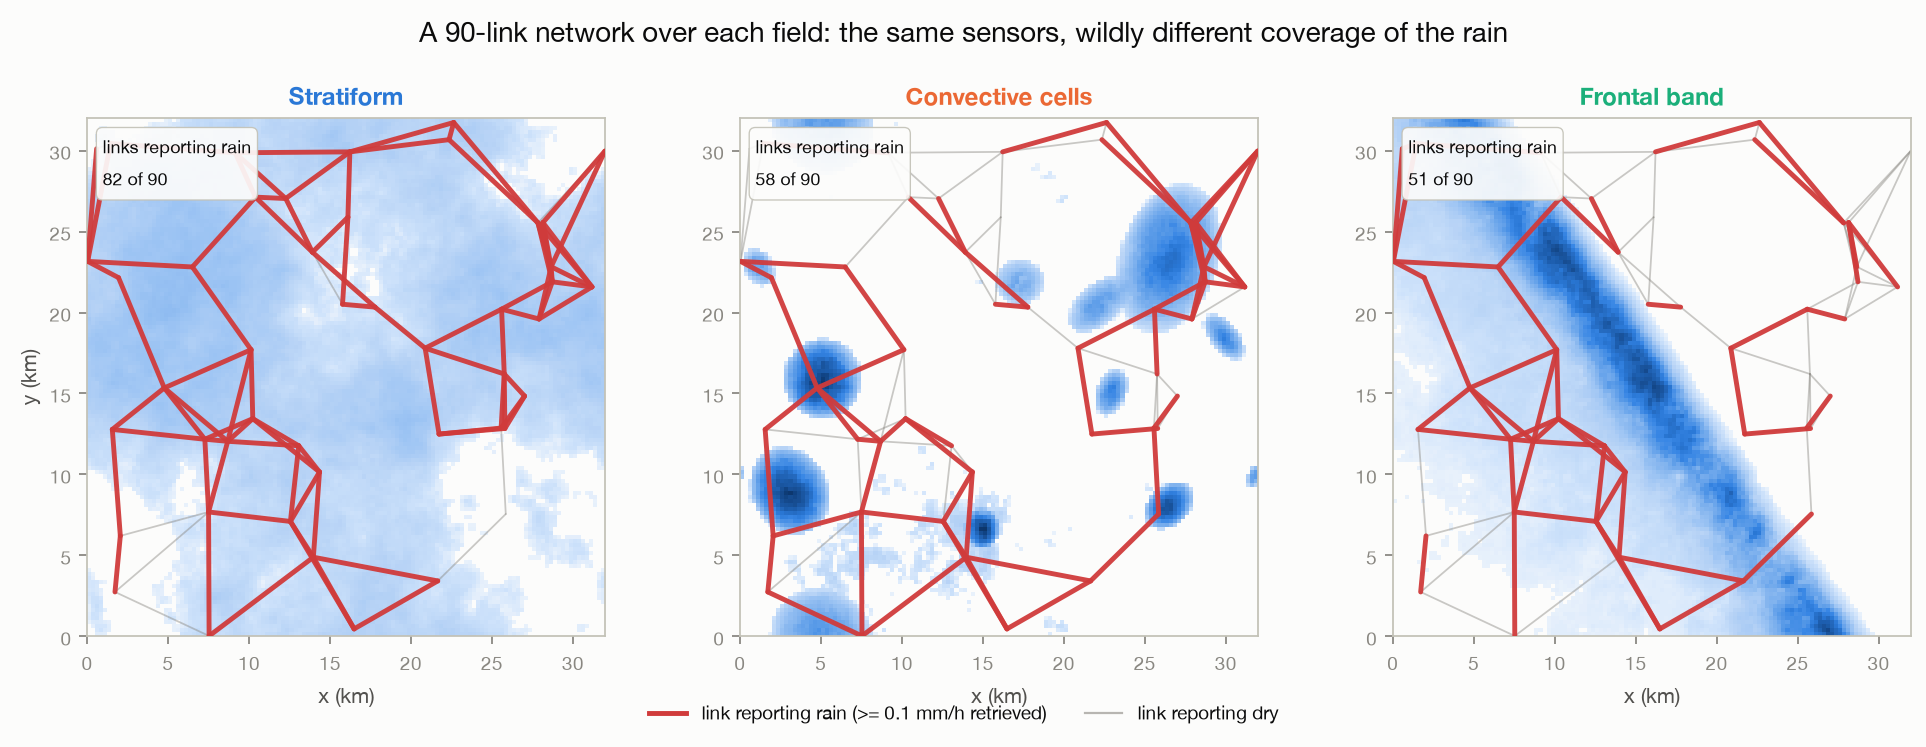

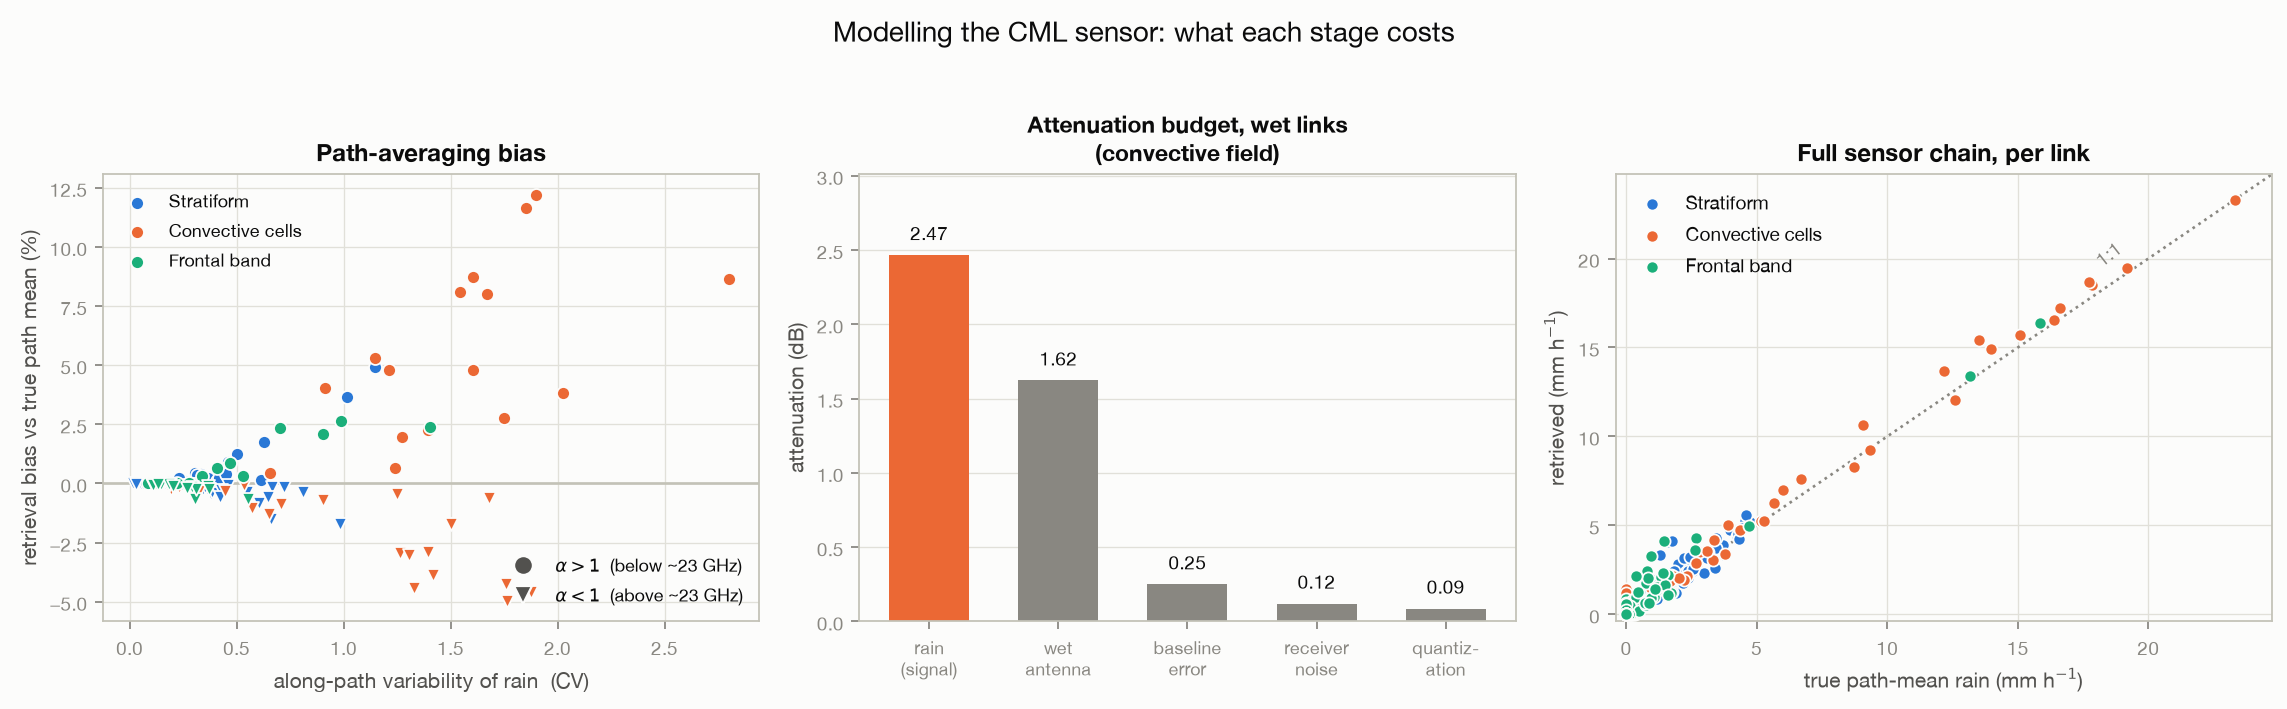

In [5]:
figures.fig_network(MODELS, fields, results, net, grid, OUT / "network.png")
figures.fig_sensor_physics(MODELS, results, net, cfg, OUT / "sensor.png")
display(Image(str(OUT / "network.png")), Image(str(OUT / "sensor.png")))

## Reconstruction: geometry or sensors?

Path-aware IDW from the *true* path averages (geometry alone) and from the *retrieved* ones
(the full chain). The difference is what the sensor physics costs.

In [6]:
pd.DataFrame({k: {"RMSE geometry alone": r["score_ideal"]["rmse"], "RMSE full chain": r["score_full"]["rmse"],
                  "correlation": r["score_full"]["corr"]} for k, r in recon.items()}).T.round(2)

,RMSE geometry alone,RMSE full chain,correlation
stratiform,1.08,1.08,0.83
convective,7.73,7.76,0.47
frontal,10.06,9.96,0.38


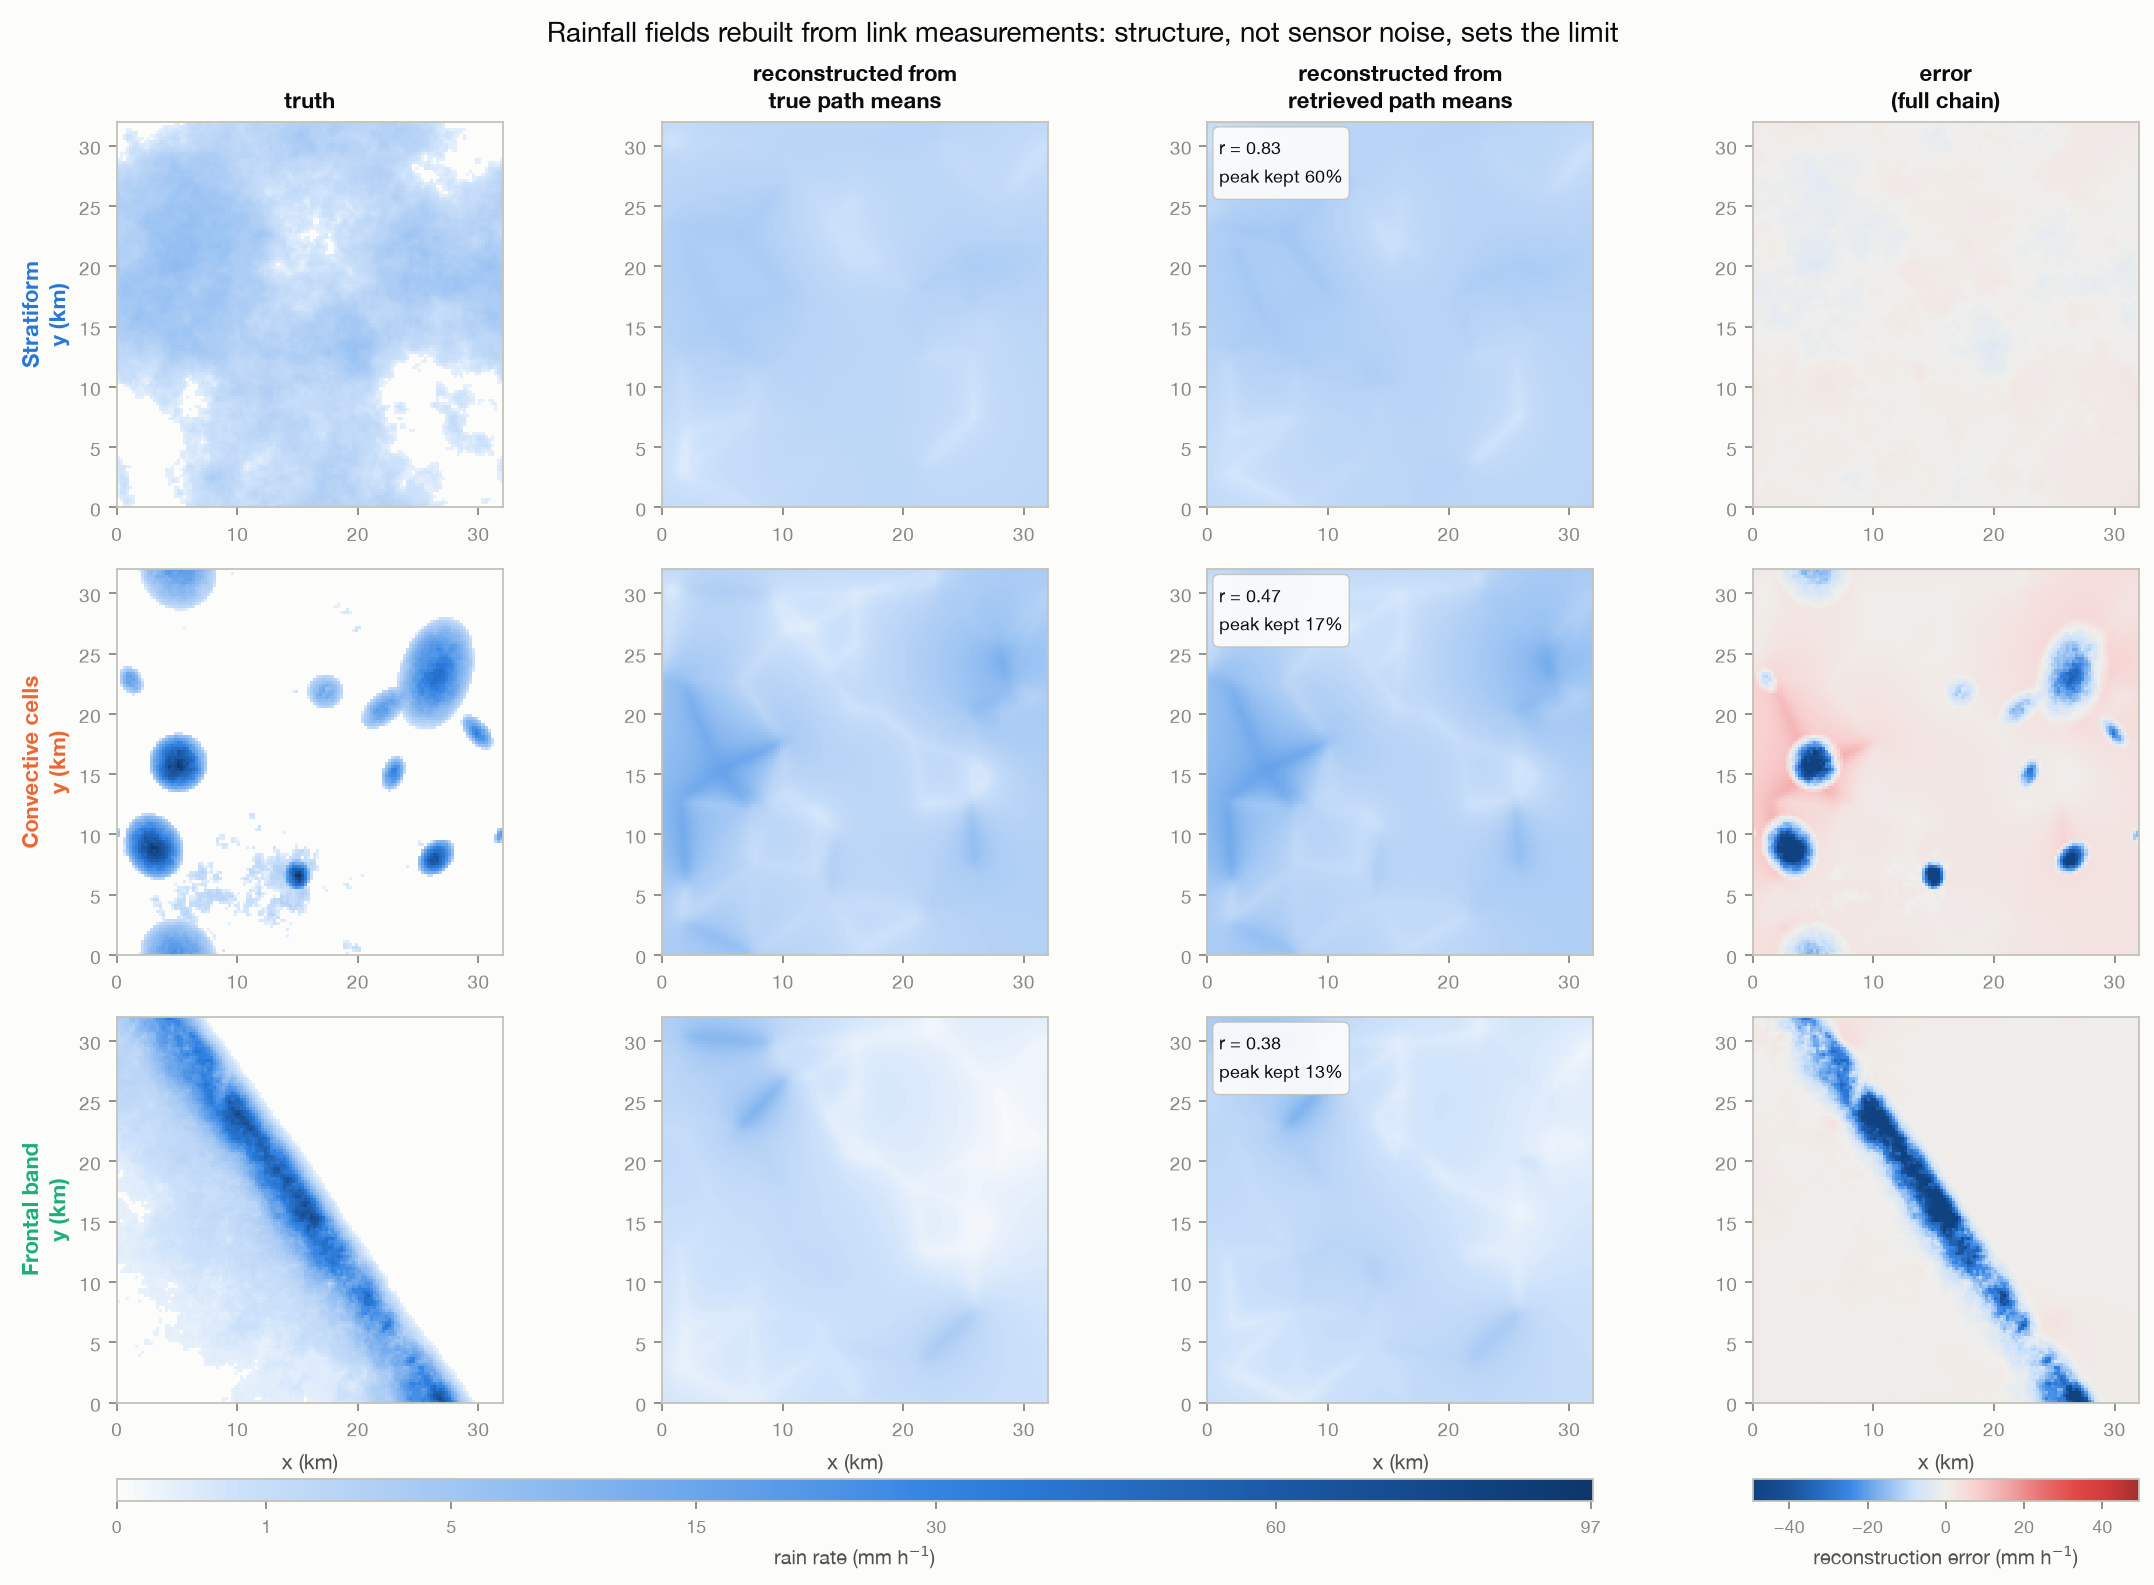

In [7]:
figures.fig_reconstruction(MODELS, fields, recon, grid, OUT / "recon.png")
display(Image(str(OUT / "recon.png")))

The density sweep (`run_demo.py`, a few minutes) and the moving fields, as committed:

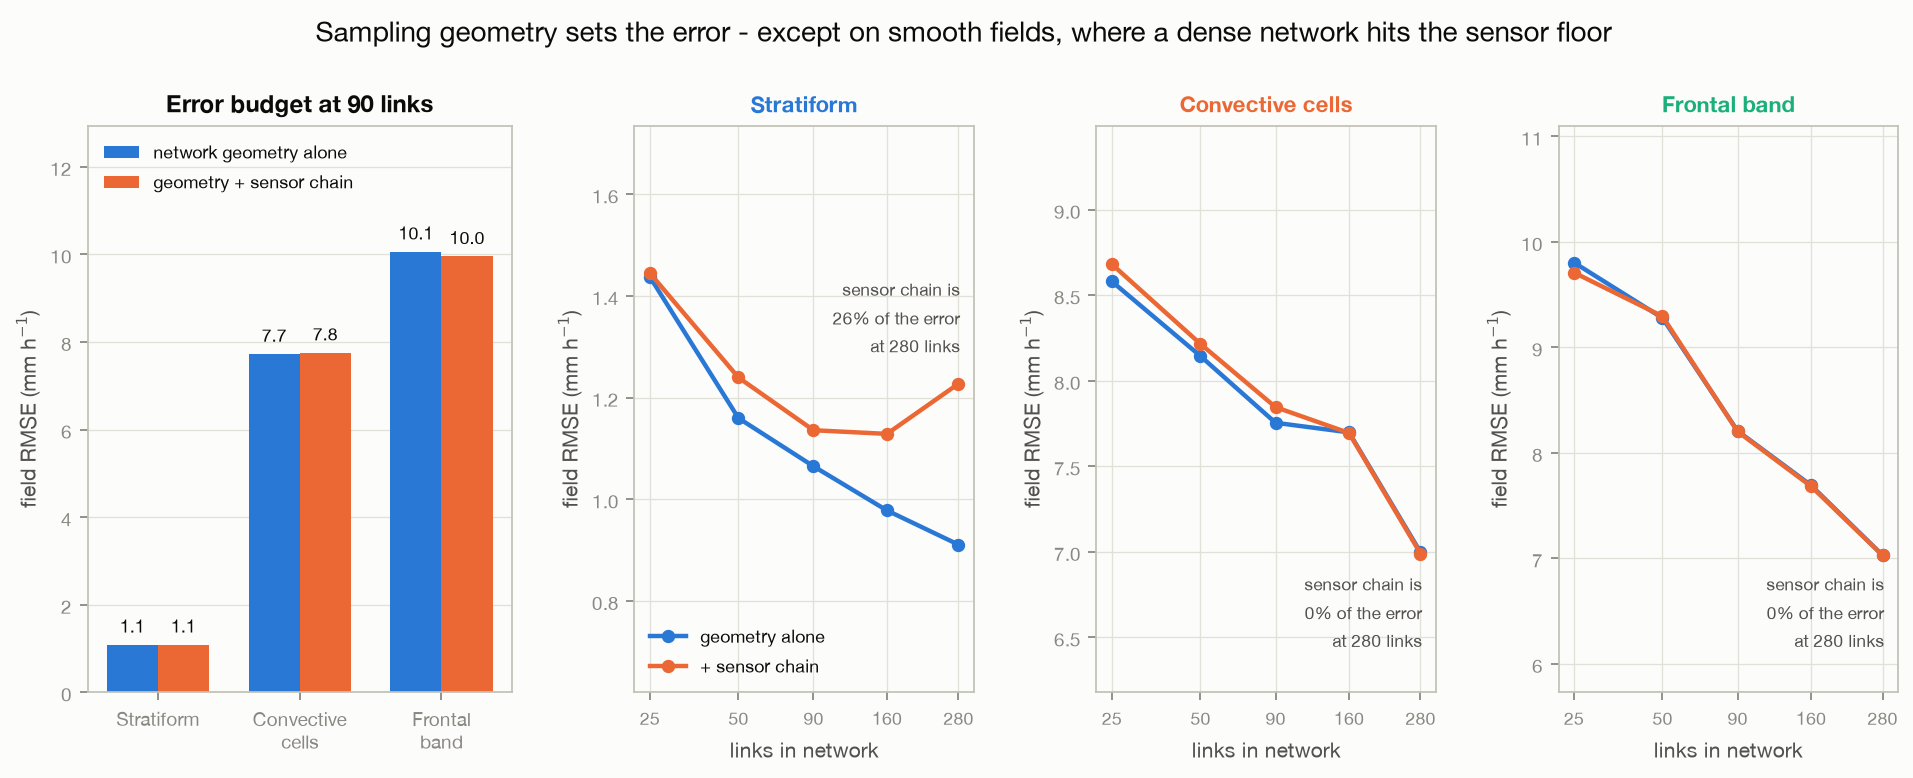

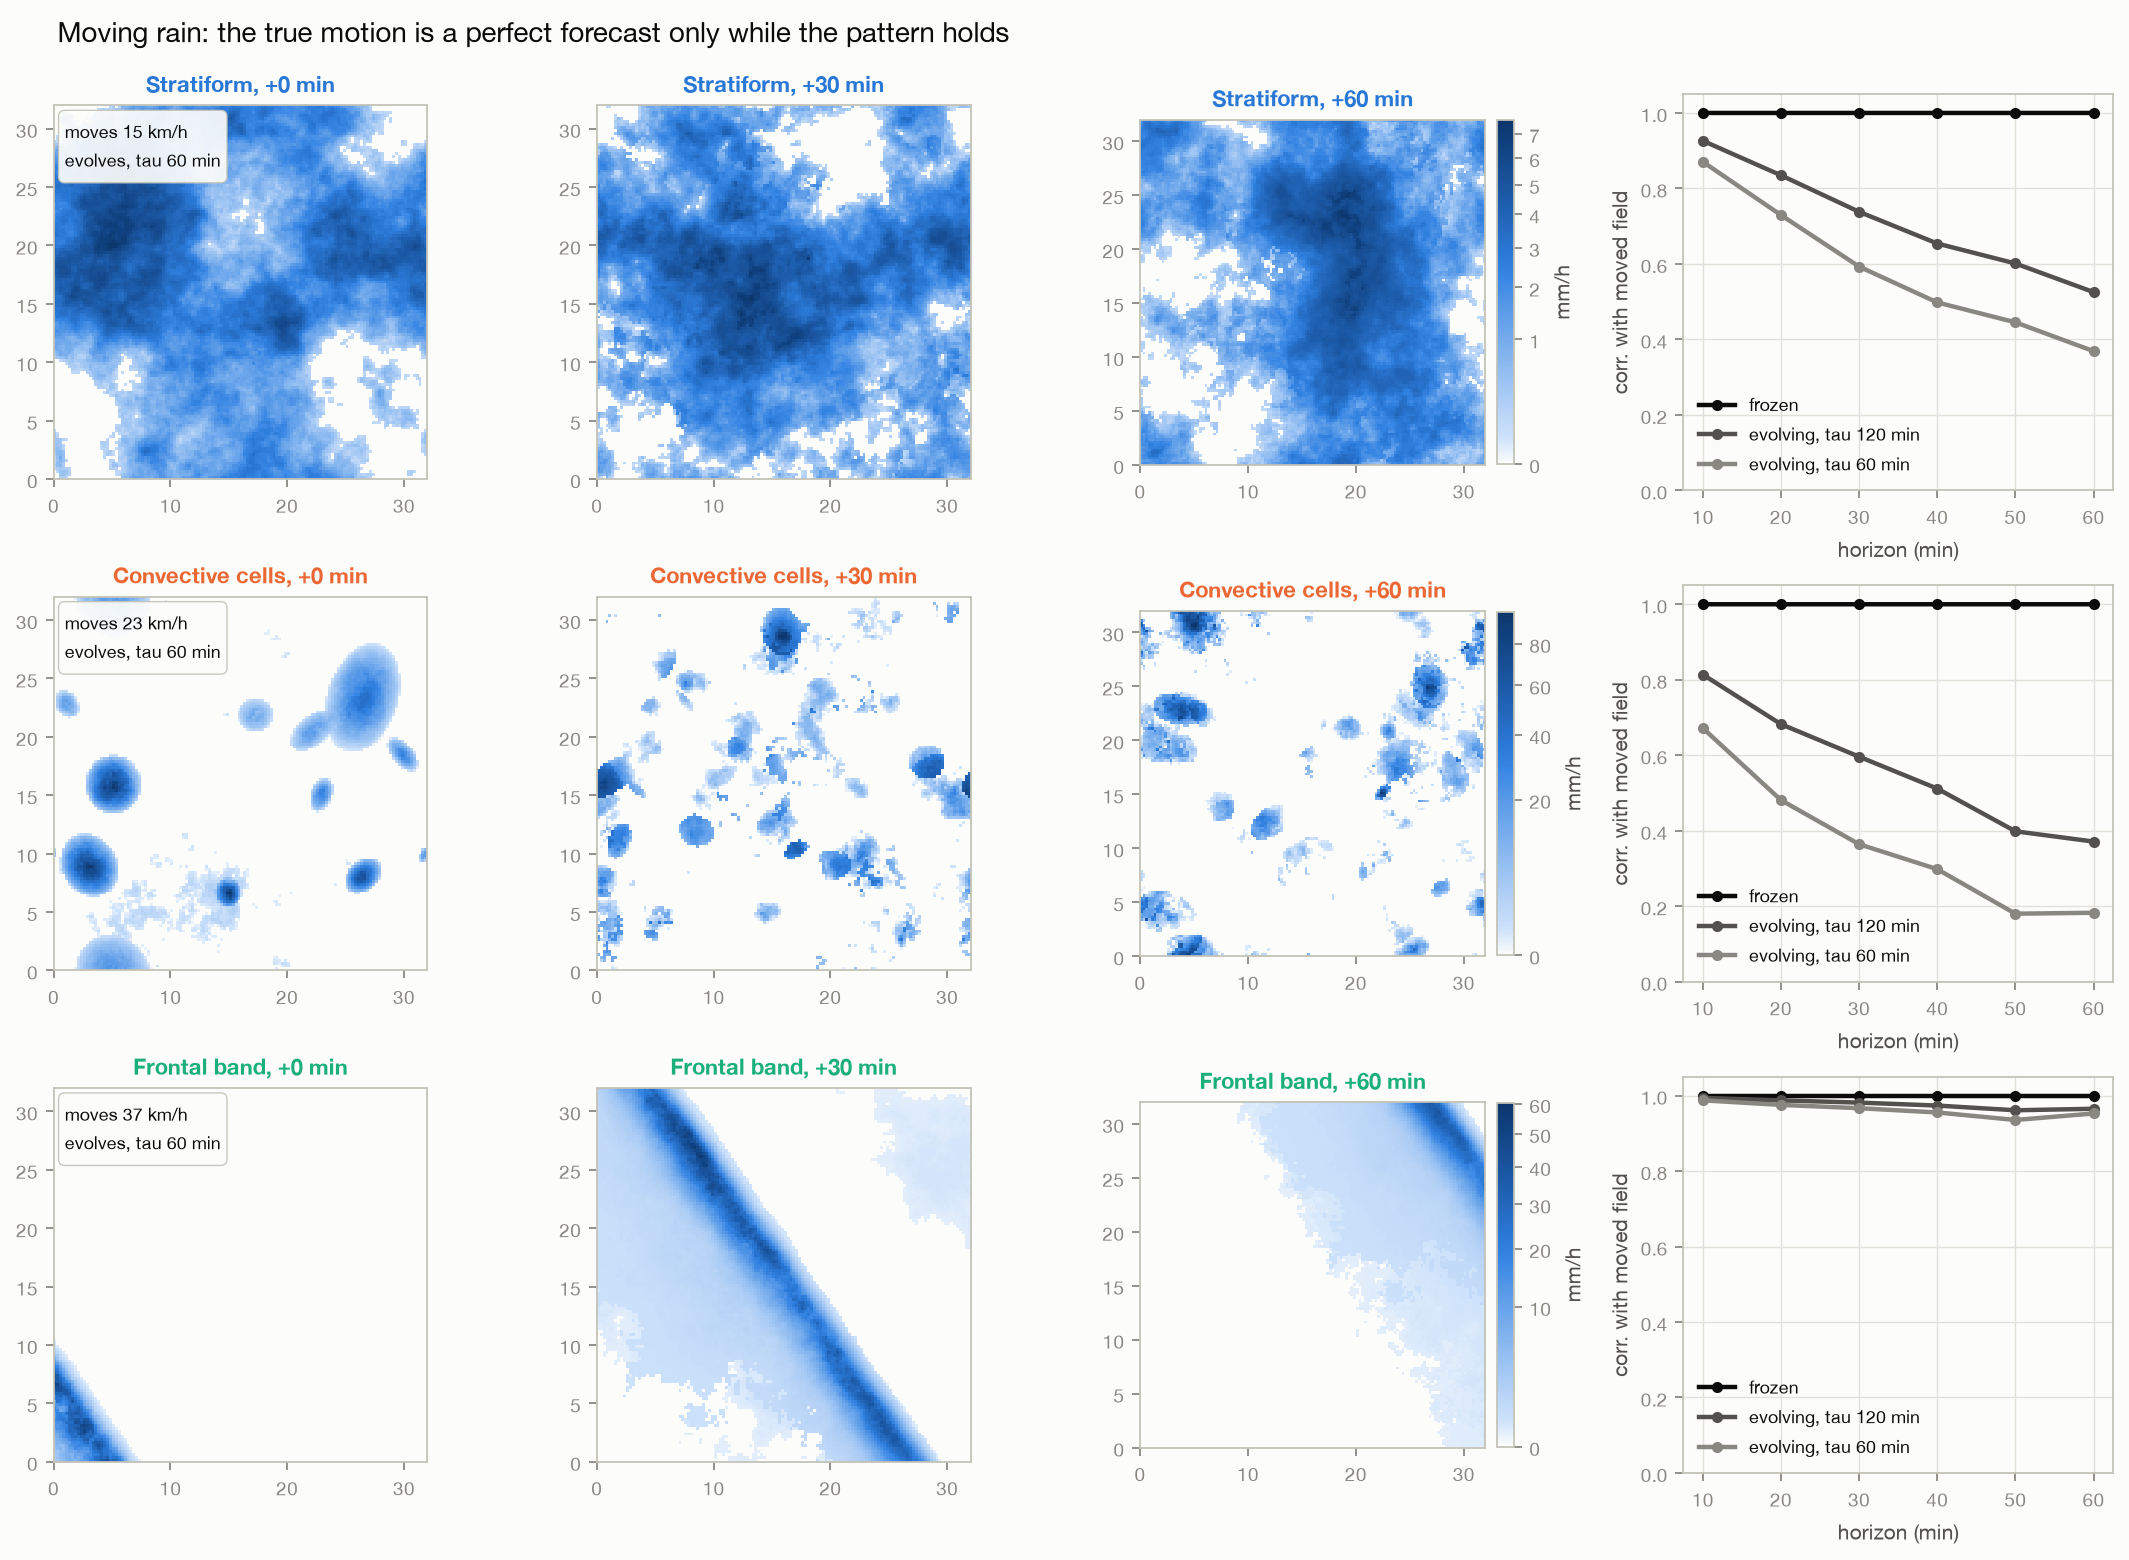

In [8]:
for f in ("fig6_error_budget.png", "fig7_moving_fields.png"):
    display(Image(str(Path("../results") / f)))